# Carga de Datos e Importaciones

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_customers = pd.read_csv('olist_customers_dataset.csv')
df_geolocation = pd.read_csv('olist_geolocation_dataset.csv')
df_items = pd.read_csv('olist_order_items_dataset.csv')
df_payments = pd.read_csv('olist_order_payments_dataset.csv')
df_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
df_products = pd.read_csv('olist_products_dataset.csv')
df_sellers = pd.read_csv('olist_sellers_dataset.csv')
df_translation = pd.read_csv('product_category_name_translation.csv')

In [ ]:
display(df_orders.head(7))

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00


In [ ]:
top_5_estados = (
    df_orders[df_orders['order_status'] == 'delivered']
    .merge(df_customers, on='customer_id', how='inner')
    ['customer_state'].value_counts().head(5)
)

print(top_5_estados)

customer_state
SP    40501
RJ    12350
MG    11354
RS     5345
PR     4923
Name: count, dtype: int64


# Manipular Fechas y Tiempos

## Convertimos los valores de Texto a Tiempo Real (DateTime)

Verificamos de que tipo son los datos de estas columnas de "Order"

In [ ]:
print(df_orders[['order_purchase_timestamp', 'order_delivered_customer_date']].dtypes)

order_purchase_timestamp         object
order_delivered_customer_date    object
dtype: object


Convertimos las columnas a formato Datetime

In [ ]:
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])
df_orders['order_estimated_delivery_date'] = pd.to_datetime(df_orders['order_estimated_delivery_date'])

Verificamo el cambio del formato de esas columnas

In [ ]:
print(df_orders[['order_purchase_timestamp', 'order_delivered_customer_date']].dtypes)

order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
dtype: object


## Calculamos los días de Envio

In [ ]:
# Calculamos la diferencia de tiempo exacta
tiempo_exacto = df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']

# Extraemos solo el número de días y creamos una nueva columna
df_orders['dias_envio'] = tiempo_exacto.dt.days

# Vemos los primeros 5 resultados
display(df_orders[['order_purchase_timestamp', 'order_delivered_customer_date', 'dias_envio']].head())

,order_purchase_timestamp,order_delivered_customer_date,dias_envio
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0


## Ahora Creamos las Alertas de Retraso

In [ ]:
# Si la fecha de entrega real es mayor a la estimada, devuelve True (Hubo retraso)
df_orders['es_retraso'] = df_orders['order_delivered_customer_date'] > df_orders['order_estimated_delivery_date']

# Vamos a contar cuántos pedidos llegaron a tiempo (False) y cuántos tarde (True)
resumen_retrasos = df_orders['es_retraso'].value_counts()
print("\nResumen de Retrasos:")
print(resumen_retrasos)


Resumen de Retrasos:
es_retraso
False    91614
True      7827
Name: count, dtype: int64


In [ ]:
display(df_orders.head(7))

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,dias_envio,es_retraso
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,False
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,16.0,False
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaT,2017-05-09,NaN,False


# Ahora realizamos una nueva seccion para realizar un "Mega-Merge" Financiero.

## Paso 1: Cargamos los archivos necesarios

In [ ]:
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_items = pd.read_csv('olist_order_items_dataset.csv')
df_products = pd.read_csv('olist_products_dataset.csv')
df_translations = pd.read_csv('product_category_name_translation.csv')

## Paso 2: Filtrar la base

In [ ]:
# Seleccionamos solo la columna 'order_id' para que el cruce sea más ligero en memoria
pedidos_entregados = df_orders[df_orders['order_status'] == 'delivered'][['order_id']]

## Paso 3: Construir la Tabla Maestra (Los cruces)

### Unimos los pedidos entregados con sus respectivos productos y precios

In [ ]:
df_cruce_1 = pd.merge(pedidos_entregados, df_items, on='order_id', how='inner')

### Unimos el resultado anterior con el catálogo de productos para obtener la categoría

In [ ]:
df_cruce_2 = pd.merge(df_cruce_1, df_products, on='product_id', how='inner')

### Unimos con el diccionario de traducción para tener los nombres legibles

In [ ]:
df_maestro = pd.merge(df_cruce_2, df_translations, on='product_category_name', how='left')

## Paso 4: Agrupacion multiple

In [ ]:
# Agrupamos por el nombre en inglés y calculamos 3 métricas distintas de una sola vez
reporte_financiero = df_maestro.groupby('product_category_name_english').agg(
    Ingreso_Total=('price', 'sum'),               # Sumamos todo el dinero generado
    Flete_Promedio=('freight_value', 'mean'),     # Calculamos el costo de envío promedio
    Cantidad_Vendida=('order_item_id', 'count')   # Contamos cuántos artículos se vendieron
).sort_values(by='Ingreso_Total', ascending=False).head(10) # Ordenamos por el que dio más dinero

## Paso 5: Formato visual para que parezca un reporte ejecutivo

In [ ]:
# Paso 5: Formato visual para que parezca un reporte ejecutivo
reporte_financiero['Ingreso_Total'] = reporte_financiero['Ingreso_Total'].round(2)
reporte_financiero['Flete_Promedio'] = reporte_financiero['Flete_Promedio'].round(2)


In [ ]:
# Mostrar el resultado final
display(reporte_financiero)

,Ingreso_Total,Flete_Promedio,Cantidad_Vendida
product_category_name_english,,,
health_beauty,1233131.72,18.91,9465
watches_gifts,1166176.98,16.75,5859
bed_bath_table,1023434.76,18.42,10953
sports_leisure,954852.55,19.38,8431
computers_accessories,888724.61,18.84,7644
furniture_decor,711927.69,20.64,8160
housewares,615628.69,21.01,6795
cool_stuff,610204.10,21.91,3718
auto,578966.65,21.86,4140


# Modelo Predictivo
Preparar y entrenar un modelo de regresión lineal utilizando el DataFrame `df_items` para predecir el precio ('price') basado en el valor del flete ('freight_value'). La tarea incluye el manejo de valores nulos, la división de datos en conjuntos de entrenamiento y prueba, y la evaluación del modelo mediante MSE y R2. Finalmente, visualizaremos los resultados y contrastaremos esto con el análisis previo del `reporte_financiero`.

## Preparar Datos para Entrenamiento

Seleccionamos las columnas 'freight_value' como característica (X) y 'price' como objetivo (y) del DataFrame 'df_items', manejar valores nulos y dividir el conjunto en entrenamiento y prueba.

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Verificar valores nulos y eliminarlos si es necesario
print('Verificando nulos en df_items:')
print(df_items[['freight_value', 'price']].isnull().sum())
df_items_clean = df_items.dropna(subset=['freight_value', 'price'])

# 2. Definir la variable independiente X y la dependiente y
X = df_items_clean[['freight_value']]
y = df_items_clean['price']

# 3. Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'\nForma de X_train: {X_train.shape}')
print(f'Forma de X_test: {X_test.shape}')
print('Preparación de datos completada.')

Verificando nulos en df_items:
freight_value    0
price            0
dtype: int64

Forma de X_train: (90120, 1)
Forma de X_test: (22530, 1)
Preparación de datos completada.


## Entrenar Modelo de Regresión Lineal

Importar LinearRegression de scikit-learn, instanciar el modelo y entrenarlo con el conjunto de entrenamiento.

In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Instanciar el modelo de Regresión Lineal
model = LinearRegression()

# 2. Entrenar el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

print('Entrenamiento del modelo completado con éxito.')

Entrenamiento del modelo completado con éxito.


## Evaluar el Modelo

Realizar predicciones en el conjunto de prueba y calcular métricas de error como el Error Cuadrático Medio (MSE) y el coeficiente de determinación (R2).

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generar predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)

# 2. Calcular el Error Cuadrático Medio (MSE)
mse = mean_squared_error(y_test, y_pred)

# 3. Calcular el coeficiente de determinación (R2)
r2 = r2_score(y_test, y_pred)

# 4. Imprimir las métricas de evaluación
print(f'Error Cuadrático Medio (MSE): {mse:.2f}')
print(f'Coeficiente R-squared (R2): {r2:.4f}')

print('\nMétricas de evaluación calculadas.')

Error Cuadrático Medio (MSE): 29694.46
Coeficiente R-squared (R2): 0.1805

Métricas de evaluación calculadas.


## Visualizar Resultados

Generar un gráfico de dispersión con los datos reales y trazar la línea de regresión obtenida por el modelo para visualizar el ajuste.

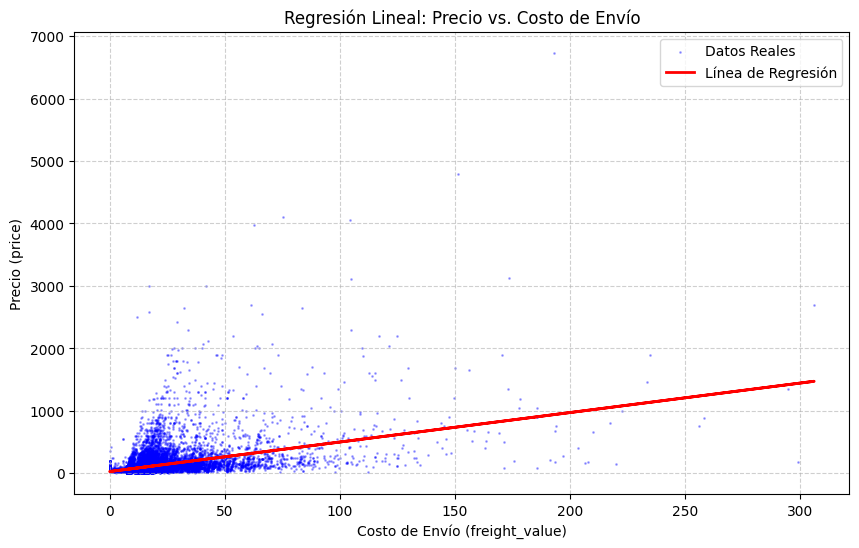

In [ ]:
import matplotlib.pyplot as plt

# 1. Configurar el tamaño de la figura
plt.figure(figsize=(10, 6))

# 2. Gráfico de dispersión para los datos reales
plt.scatter(X_test, y_test, color='blue', s=1, alpha=0.3, label='Datos Reales')

# 3. Graficar la línea de regresión (predicciones)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Línea de Regresión')

# 4. Definir etiquetas y título
plt.xlabel('Costo de Envío (freight_value)')
plt.ylabel('Precio (price)')
plt.title('Regresión Lineal: Precio vs. Costo de Envío')

# 5. Agregar leyenda y mostrar gráfico
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Conclusión General del Proyecto

Hemos completado un ciclo completo de análisis de datos y ciencia de datos:

1.  **Carga y Exploración:** Importamos los múltiples datasets de Olist y exploramos la distribución de pedidos por estado.
2.  **Preparación de Datos:** Realizamos transformaciones temporales para calcular tiempos de envío y detectar retrasos.
3.  **Análisis de Negocio:** Construimos un **`reporte_financiero`** mediante un "Mega-Merge", identificando las categorías con mayores ingresos y costos de flete.
4.  **Modelado Predictivo:** Entrenamos un modelo de Regresión Lineal para entender la relación entre el flete y el precio.

**Resultado Final:** Aunque el modelo mostró una correlación positiva, el análisis del `reporte_financiero` y las métricas del modelo (R2 = 0.18) sugieren que el precio es influenciado por factores mucho más complejos que solo el costo de envío. Este flujo sirve como base para implementar modelos más avanzados en el futuro.